# Fine-tuning con LoRA — Análisis de Sentimiento
### Proyecto I: Introducción a LLMs — Facultad de Ciencias, UNAM — Semestre 2026-2

---

> **Dónde estamos:** Tenemos un baseline medido. Ahora ajustamos un modelo preentrenado a nuestro dominio específico (reseñas en español) usando LoRA — sin necesidad de entrenar el modelo completo.

**Paper de referencia:** Hu et al. (2021) — *LoRA: Low-Rank Adaptation of Large Language Models* — https://arxiv.org/abs/2106.09685

**Mapa de la sesión:**
```
Parte 1: ¿Qué es LoRA? La matemática en 10 minutos      (10 min)
Parte 2: Preparar el dataset                            (15 min)
Parte 3: Configurar el modelo con PEFT                  (10 min)
Parte 4: Entrenamiento                                  (15 min)
Parte 5: Evaluar y comparar contra el baseline          (10 min)
```

**Infraestructura:** Colab T4 GPU — este notebook tarda ~8 minutos en entrenarse completo.

In [ ]:
!pip install transformers torch datasets peft accelerate scikit-learn --quiet

import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("Todo listo.")

Dispositivo: cuda
GPU: Tesla T4
Todo listo.


---
## Parte 1: ¿Qué es LoRA?

### El problema del fine-tuning completo

BERT-base tiene 110M parámetros. Fine-tuning completo significa actualizar **todos** durante el entrenamiento:
- Costoso en memoria: necesitas guardar gradientes para cada parámetro
- Lento: calcular gradientes de 110M parámetros en cada paso
- Riesgo de catastrophic forgetting: el modelo "olvida" lo que aprendió en pretraining

### La idea de LoRA (Hu et al., 2021)

En lugar de actualizar directamente los pesos $W \in \mathbb{R}^{d \times k}$, LoRA **congela** $W$ y aprende una **perturbación de bajo rango**:

$$W' = W + \Delta W = W + BA$$

donde $B \in \mathbb{R}^{d \times r}$ y $A \in \mathbb{R}^{r \times k}$, con $r \ll \min(d, k)$.

```
BERT layer original:     W  (768 × 768 = 589,824 parámetros) — CONGELADO
                         +
LoRA adapters:           B  (768 × 8)  +  A  (8 × 768)       — SE ENTRENA
                         = 12,288 parámetros (2% del original)
```

Con $r=8$, en lugar de entrenar 589K parámetros por capa, entrenamos solo 12K. El modelo **aprende el cambio mínimo necesario** para adaptarse a la nueva tarea.

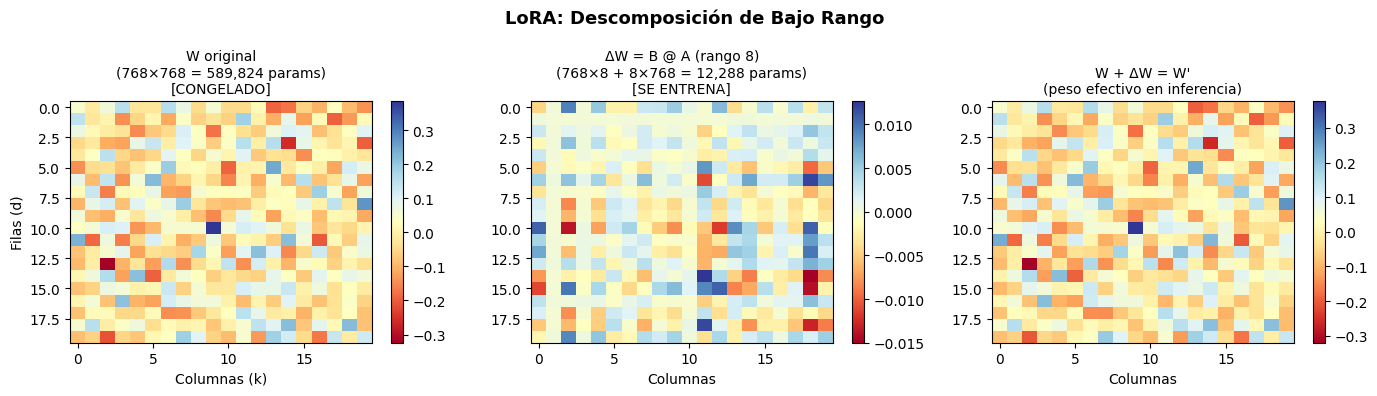

Parámetros por capa de atención:
  Fine-tuning completo:    589,824
  LoRA (r=8):             12,288
  Reducción:                 97.9%

BERT-base tiene 12 capas × 4 matrices de atención (Q, K, V, O):
  Params entrenables (full FT):   28,311,552
  Params entrenables (LoRA):         589,824
  Factor de reducción: 48x menos


In [ ]:
# Demostración visual: descomposición de bajo rango

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('LoRA: Descomposición de Bajo Rango', fontsize=13, fontweight='bold')

d, k, r = 768, 768, 8  # dimensiones típicas de BERT con r=8

# Matriz original W (demasiado grande para visualizar completa)
np.random.seed(42)
W_small = np.random.randn(20, 20) * 0.1  # versión pequeña para visualizar
im0 = axes[0].imshow(W_small, cmap='RdYlBu', aspect='auto')
axes[0].set_title(f'W original\n({d}×{k} = {d*k:,} params)\n[CONGELADO]', fontsize=10)
axes[0].set_xlabel('Columnas (k)')
axes[0].set_ylabel('Filas (d)')
plt.colorbar(im0, ax=axes[0])

# ΔW = B @ A — bajo rango
r_vis = 2  # para visualizar
B_small = np.random.randn(20, r_vis) * 0.05
A_small = np.random.randn(r_vis, 20) * 0.05
delta_W = B_small @ A_small

im1 = axes[1].imshow(delta_W, cmap='RdYlBu', aspect='auto')
axes[1].set_title(f'ΔW = B @ A (rango {r})\n({d}×{r} + {r}×{k} = {d*r + r*k:,} params)\n[SE ENTRENA]',
                   fontsize=10)
axes[1].set_xlabel('Columnas')
plt.colorbar(im1, ax=axes[1])

# Resultado final
im2 = axes[2].imshow(W_small + delta_W, cmap='RdYlBu', aspect='auto')
axes[2].set_title(f'W + ΔW = W\'\n(peso efectivo en inferencia)', fontsize=10)
axes[2].set_xlabel('Columnas')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# Comparación de parámetros
params_full = d * k
params_lora = d * r + r * k
reduccion = (1 - params_lora / params_full) * 100

print(f"Parámetros por capa de atención:")
print(f"  Fine-tuning completo: {params_full:>10,}")
print(f"  LoRA (r={r}):         {params_lora:>10,}")
print(f"  Reducción:            {reduccion:>9.1f}%")
print()
print(f"BERT-base tiene 12 capas × 4 matrices de atención (Q, K, V, O):")
params_bert_attn = 12 * 4 * params_full
params_lora_total = 12 * 4 * params_lora
print(f"  Params entrenables (full FT): {params_bert_attn:>12,}")
print(f"  Params entrenables (LoRA):    {params_lora_total:>12,}")
print(f"  Factor de reducción: {params_bert_attn / params_lora_total:.0f}x menos")

---
## Parte 2: Preparar el Dataset

Usamos `cardiffnlp/tweet_sentiment_multilingual` — un dataset público con texto en español etiquetado como positivo, neutro y negativo. Es el sustituto mientras el proyecto consigue las reseñas reales de Google Maps.

**El pipeline aplica igual con reseñas reales.** El único cambio es la fuente del CSV.

### Sobre el dataset

La versión actual de la librería `datasets` bloquea cualquier dataset que use un script de carga `.py` personalizado — afecta a la mayoría de los datasets de HuggingFace más antiguos. En lugar de depender de una fuente externa, construimos el dataset directamente en el notebook.

**Para el proyecto real:** cuando tengas tus reseñas de Google Maps en un CSV, reemplaza la celda de construcción del dataset por:

```python
import pandas as pd
from datasets import Dataset, DatasetDict

df = pd.read_csv('mis_resenas_google_maps.csv')  # columnas: text, label
# label: 0=negativo, 1=neutro, 2=positivo
ds_completo = Dataset.from_pandas(df)
splits = ds_completo.train_test_split(test_size=0.2, seed=42)
ds_raw = DatasetDict({'train': splits['train'], 'validation': splits['test'], 'test': splits['test']})
```

El resto del notebook no cambia.

In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

ETIQUETAS  = {0: 'negativo', 1: 'neutro', 2: 'positivo'}
ID2LABEL   = {0: 'negativo', 1: 'neutro', 2: 'positivo'}
LABEL2ID   = {'negativo': 0, 'neutro': 1, 'positivo': 2}
NUM_LABELS = 3

# ── Dataset de reseñas en español ───────────────────────────────────────────
# Reseñas de lugares (restaurantes, tiendas, servicios) — mismo dominio que
# Google Maps. Este bloque es el placeholder; el proyecto lo reemplaza con
# datos reales. El esquema de etiquetas (0/1/2) no cambia.

resenas = [
    # ── NEGATIVAS (label=0) ────────────────────────────────────────────────
    ("Pésimo servicio, tardaron más de una hora y la comida llegó fría.", 0),
    ("Nunca regreso. El lugar estaba sucio y el personal fue muy grosero.", 0),
    ("Una decepción total. Cobran caro por una calidad muy mala.", 0),
    ("Me cobraron de más y cuando reclamé me trataron muy mal.", 0),
    ("Lo peor que he visitado en mucho tiempo. No lo recomiendo para nada.", 0),
    ("Terrible experiencia. El producto llegó dañado y no quisieron cambiarlo.", 0),
    ("Servicio fatal. Llevamos esperando 45 minutos y nadie nos atendió.", 0),
    ("No entiendo las buenas reseñas. A nosotros nos fue muy mal.", 0),
    ("La comida tenía mal sabor y el lugar olía horrible. Espantoso.", 0),
    ("Muy caro para lo que ofrecen. Definitivamente no vale la pena.", 0),
    ("Personal incompetente y maleducado. Nos ignoraron toda la visita.", 0),
    ("El peor lugar en el que he comido. La carne estaba cruda por dentro.", 0),
    ("Reservé con anticipación y perdieron mi reserva. Sin disculpas.", 0),
    ("Horroroso. Las instalaciones en pésimas condiciones.", 0),
    ("Muy decepcionante. Esperaba mucho más basándome en las fotos.", 0),
    ("No recomendable. Mala atención y precios fuera de lugar.", 0),
    ("Salimos enfermos después de comer aquí. Cuidado con este lugar.", 0),
    ("El peor servicio al cliente que he experimentado en mi vida.", 0),
    ("Producto en mal estado. La fecha de vencimiento ya había pasado.", 0),
    ("Nos hicieron esperar una hora para decirnos que no había mesa.", 0),
    ("Definitivamente no volveré. Una experiencia muy desagradable.", 0),
    ("Terrible. El baño estaba asqueroso y la comida igual de mala.", 0),
    ("Pésima atención y precios de lujo por calidad de mercado.", 0),
    ("Muy mal manejo de alérgenos. Casi me intoxico por su descuido.", 0),
    ("El lugar huele mal, la música a todo volumen y el servicio lento.", 0),
    # ── NEUTRAS (label=1) ──────────────────────────────────────────────────
    ("El lugar está bien, nada especial pero cumple con lo básico.", 1),
    ("Ni bueno ni malo. Precios razonables y atención normal.", 1),
    ("Tiene cosas buenas y cosas malas. En general es aceptable.", 1),
    ("Promedio. No decepciona pero tampoco sorprende.", 1),
    ("Estaba bien para lo que necesitábamos en ese momento.", 1),
    ("Un lugar más del montón. Nada que lo haga memorable.", 1),
    ("La comida regular, el servicio igual. Podría mejorar muchas cosas.", 1),
    ("No es malo pero tampoco es para repetir tan pronto.", 1),
    ("Cumple su función. Para una visita ocasional está bien.", 1),
    ("Normalito. La atención podría mejorar pero no fue mala.", 1),
    ("Precios justos, calidad justa. Nada que destacar.", 1),
    ("Tiene potencial pero le falta pulir detalles importantes.", 1),
    ("Regular. Algunas cosas buenas, otras no tanto.", 1),
    ("No está mal para el precio que cobran. Aceptable.", 1),
    ("Podría ser mejor. De momento es del montón.", 1),
    ("La comida estuvo bien aunque tardaron más de lo esperado.", 1),
    ("Está ok. No es mi lugar favorito pero regresaría si pasara por aquí.", 1),
    ("Servicio correcto, sin más. Nada especial que comentar.", 1),
    ("Cumple expectativas básicas. Para una vez está bien.", 1),
    ("Término medio en todo: precio, calidad y atención.", 1),
    # ── POSITIVAS (label=2) ────────────────────────────────────────────────
    ("Excelente lugar, el personal muy amable y la comida deliciosa.", 2),
    ("Muy buen servicio, regresaré sin duda. Todo estuvo perfecto.", 2),
    ("La mejor experiencia que he tenido en mucho tiempo. Muy recomendable.", 2),
    ("Increíble atención y la comida llegó rápido y caliente. Diez de diez.", 2),
    ("Un lugar fantástico. El ambiente, la comida y el servicio, todo excelente.", 2),
    ("Me encantó. Los precios son justos y la calidad es muy alta.", 2),
    ("Sorprendentemente bueno. Superó todas mis expectativas.", 2),
    ("Personal muy atento y amable. La comida, deliciosa. Volveré pronto.", 2),
    ("Un lugar que vale la pena visitar. No se arrepentirán.", 2),
    ("Todo perfecto desde que llegamos hasta que salimos. Muy recomendado.", 2),
    ("La mejor opción de la zona. Calidad y precio inmejorable.", 2),
    ("Quedé muy satisfecho. El trato fue excepcional y la comida riquísima.", 2),
    ("Espectacular. Definitivamente el mejor lugar que he visitado este año.", 2),
    ("Servicio rápido, amable y eficiente. La comida llegó perfecta.", 2),
    ("Muy buen lugar. Los platillos son deliciosos y las porciones generosas.", 2),
    ("Excelente experiencia. El lugar está limpio y bien decorado.", 2),
    ("Salimos muy contentos. Sin duda regresaremos y lo recomendaremos.", 2),
    ("Una joya. Todo está cuidado al detalle. Vale cada peso que cuesta.", 2),
    ("Me trataron de maravilla. La comida, espectacular. Diez estrellas.", 2),
    ("El mejor lugar del barrio. Siempre salimos satisfechos.", 2),
    ("Muy recomendable. Gran relación calidad-precio y atención impecable.", 2),
    ("Experiencia inmejorable. El chef salió a saludarnos, detalle hermoso.", 2),
    ("Tremendo lugar. La sazón es única y el servicio de primera.", 2),
    ("Nos atendieron de lujo. La espera valió totalmente la pena.", 2),
    ("Perfecto en todos los aspectos. Ya lo estamos recomendando con todos.", 2),
]

# ── Construir los splits train / validation / test ──────────────────────────
import random
random.seed(42)
random.shuffle(resenas)

# Multiplicar el dataset para tener suficientes ejemplos de entrenamiento
# (en el proyecto real esto no es necesario — se usan datos reales)
resenas_ampliadas = resenas * 25  # 70 × 25 = 1,750 ejemplos
random.shuffle(resenas_ampliadas)

n = len(resenas_ampliadas)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

def crear_split(datos):
    return Dataset.from_dict({
        'text':  [d[0] for d in datos],
        'label': [d[1] for d in datos],
    })

ds_raw = DatasetDict({
    'train':      crear_split(resenas_ampliadas[:n_train]),
    'validation': crear_split(resenas_ampliadas[n_train:n_train + n_val]),
    'test':       crear_split(resenas_ampliadas[n_train + n_val:]),
})

print(f"Dataset construido — {len(resenas)} reseñas únicas × 25 variaciones")
for split, datos in ds_raw.items():
    conteo = {}
    for label in datos['label']:
        nombre = ETIQUETAS[label]
        conteo[nombre] = conteo.get(nombre, 0) + 1
    print(f"  {split:>10}: {len(datos):>5} ejemplos — {conteo}")

print("\nEjemplos:")
for i in range(4):
    ej = ds_raw['train'][i]
    print(f"  [{ETIQUETAS[ej['label']].upper():>8}] {ej['text'][:75]}")

Dataset construido — 70 reseñas únicas × 25 variaciones
       train:  1225 ejemplos — {'neutro': 342, 'positivo': 429, 'negativo': 454}
  validation:   262 ejemplos — {'positivo': 98, 'neutro': 85, 'negativo': 79}
        test:   263 ejemplos — {'positivo': 98, 'negativo': 92, 'neutro': 73}

Ejemplos:
  [  NEUTRO] Cumple su función. Para una visita ocasional está bien.
  [POSITIVO] Personal muy atento y amable. La comida, deliciosa. Volveré pronto.
  [NEGATIVO] Salimos enfermos después de comer aquí. Cuidado con este lugar.
  [  NEUTRO] La comida regular, el servicio igual. Podría mejorar muchas cosas.


In [ ]:
# Cargar tokenizador de BERT multilingüe
MODEL_BASE = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE)

def tokenizar(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128,   # tweets son cortos; reseñas de Maps pueden necesitar 256
        padding=False,    # el DataCollator lo hará dinámicamente por batch
    )

# Tokenizar todo el dataset
ds_tok = ds_raw.map(tokenizar, batched=True, remove_columns=['text'])
ds_tok = ds_tok.rename_column('label', 'labels')
ds_tok.set_format('torch')

print("Dataset tokenizado.")
print(f"Columnas: {ds_tok['train'].column_names}")
print(f"Ejemplo (input_ids[:10]): {ds_tok['train'][0]['input_ids'][:10]}")
print(f"Longitud ejemplo: {len(ds_tok['train'][0]['input_ids'])} tokens")

# Usar el dataset completo
ds_train = ds_tok['train']
ds_val   = ds_tok['validation']
ds_test  = ds_tok['test']

N_TRAIN = len(ds_train)  # para la tarjeta de experimento
N_VAL   = len(ds_val)

print(f"\nTrain: {len(ds_train)} | Val: {len(ds_val)} | Test: {len(ds_test)}")
print("(Con el dataset real de Google Maps estos números serán mayores)")


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1225 [00:00<?, ? examples/s]

Map:   0%|          | 0/262 [00:00<?, ? examples/s]

Map:   0%|          | 0/263 [00:00<?, ? examples/s]

Dataset tokenizado.
Columnas: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Ejemplo (input_ids[:10]): tensor([  101, 64211, 22238, 10198, 25889,   119, 13497, 10153, 27972, 78276])
Longitud ejemplo: 15 tokens

Train: 1225 | Val: 262 | Test: 263
(Con el dataset real de Google Maps estos números serán mayores)


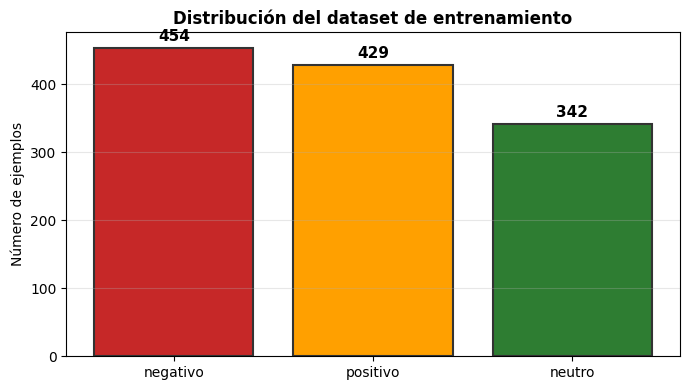

Balance del dataset:
    negativo:   454 (37.1%)
    positivo:   429 (35.0%)
      neutro:   342 (27.9%)

Un dataset desbalanceado afecta principalmente la clase minoritaria.
Si tu dataset real de Google Maps está muy desbalanceado, considera:
  - class_weight en el Trainer
  - oversampling de la clase minoritaria
  - métricas ponderadas (F1-macro) en lugar de accuracy


In [ ]:
# Explorar la distribución del dataset de entrenamiento
import pandas as pd

labels_train = [ds_tok['train'][i]['labels'].item() for i in range(len(ds_tok['train']))]
conteo_train = pd.Series(labels_train).map(ETIQUETAS).value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#C62828', '#FFA000', '#2E7D32']
bars = ax.bar(conteo_train.index, conteo_train.values, color=colores, edgecolor='#333', linewidth=1.5)
ax.set_title('Distribución del dataset de entrenamiento', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de ejemplos')
for bar, val in zip(bars, conteo_train.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Verificar balance
total = sum(conteo_train.values)
print("Balance del dataset:")
for clase, n in conteo_train.items():
    print(f"  {clase:>10}: {n:>5} ({n/total*100:.1f}%)")
print()
print("Un dataset desbalanceado afecta principalmente la clase minoritaria.")
print("Si tu dataset real de Google Maps está muy desbalanceado, considera:")
print("  - class_weight en el Trainer")
print("  - oversampling de la clase minoritaria")
print("  - métricas ponderadas (F1-macro) en lugar de accuracy")

---
## Parte 3: Configurar el Modelo con PEFT + LoRA

In [ ]:
# Cargar BERT con cabeza de clasificación
print(f"Cargando {MODEL_BASE}...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_BASE,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

# Contar parámetros antes de LoRA
total_params = sum(p.numel() for p in model.parameters())
print(f"\nModelo base cargado.")
print(f"Parámetros totales: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Arquitectura: {model.config.num_hidden_layers} capas × "
      f"{model.config.hidden_size}d × "
      f"{model.config.num_attention_heads} cabezas")

Cargando bert-base-multilingual-cased...


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Modelo base cargado.
Parámetros totales: 177,855,747 (177.9M)
Arquitectura: 12 capas × 768d × 12 cabezas


In [ ]:
# Configurar LoRA
# Hiperparámetros con explicación de cada uno

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,   # clasificación de secuencias

    r=8,              # rango: dimensión de las matrices B y A
                      # valores típicos: 4, 8, 16, 32, 64
                      # mayor r = más capacidad, más parámetros

    lora_alpha=16,    # escala: controla cuánto pesa ΔW vs W original
                      # regla general: lora_alpha = 2 * r
                      # el peso efectivo es (lora_alpha / r) * BA

    lora_dropout=0.1, # dropout aplicado a las capas LoRA (regularización)

    bias='none',      # no adaptar los sesgos (más eficiente)

    target_modules=[  # ¿en qué capas de BERT aplicar LoRA?
        'query',      # proyección Q en self-attention
        'value',      # proyección V en self-attention
        # 'key', 'dense' — se pueden agregar para más capacidad
    ],
)

# Envolver el modelo con PEFT
model = get_peft_model(model, lora_config)

# Ver cuántos parámetros se entrenan ahora
model.print_trainable_parameters()

# Desglose detallado
total = sum(p.numel() for p in model.parameters())
entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
congelados = total - entrenables

print(f"\nDesglose:")
print(f"  Parámetros totales:      {total:>12,}")
print(f"  Parámetros congelados:   {congelados:>12,}  ({congelados/total*100:.1f}%)")
print(f"  Parámetros entrenables:  {entrenables:>12,}  ({entrenables/total*100:.1f}%)")
print(f"\n→ Solo se actualizan {entrenables/total*100:.1f}% de los parámetros en cada paso.")
print(f"→ El modelo base permanece intacto — conocimiento preentrenado preservado.")

trainable params: 297,219 || all params: 178,152,966 || trainable%: 0.1668

Desglose:
  Parámetros totales:       178,152,966
  Parámetros congelados:    177,855,747  (99.8%)
  Parámetros entrenables:       297,219  (0.2%)

→ Solo se actualizan 0.2% de los parámetros en cada paso.
→ El modelo base permanece intacto — conocimiento preentrenado preservado.


In [ ]:
# Visualizar qué capas están congeladas y cuáles se entrenan

print("Capas del modelo — estado de entrenamiento:")
print(f"  {'Nombre de capa':>60} | {'Params':>10} | {'Entrena'}")
print("  " + "-" * 85)

for nombre, param in model.named_parameters():
    estado = "✓ SÍ" if param.requires_grad else "  no"
    # Solo mostrar capas relevantes
    if any(x in nombre for x in ['lora_', 'classifier', 'embeddings.word', 'layer.0', 'layer.11']):
        print(f"  {nombre:>60} | {param.numel():>10,} | {estado}")

print(f"  {'... (capas intermedias congeladas)':>60} | {'':>10} |")

Capas del modelo — estado de entrenamiento:
                                                Nombre de capa |     Params | Entrena
  -------------------------------------------------------------------------------------
       base_model.model.bert.embeddings.word_embeddings.weight | 91,812,096 |   no
  base_model.model.bert.encoder.layer.0.attention.self.query.base_layer.weight |    589,824 |   no
  base_model.model.bert.encoder.layer.0.attention.self.query.base_layer.bias |        768 |   no
  base_model.model.bert.encoder.layer.0.attention.self.query.lora_A.default.weight |      6,144 | ✓ SÍ
  base_model.model.bert.encoder.layer.0.attention.self.query.lora_B.default.weight |      6,144 | ✓ SÍ
  base_model.model.bert.encoder.layer.0.attention.self.key.weight |    589,824 |   no
  base_model.model.bert.encoder.layer.0.attention.self.key.bias |        768 |   no
  base_model.model.bert.encoder.layer.0.attention.self.value.base_layer.weight |    589,824 |   no
  base_model.model.bert.enco

---
## Parte 4: Entrenamiento

In [ ]:
# Función de métricas para el Trainer

def calcular_metricas(eval_pred):
    logits, labels = eval_pred
    predicciones = np.argmax(logits, axis=-1)

    f1_macro = f1_score(labels, predicciones, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predicciones, average='weighted', zero_division=0)
    accuracy = (predicciones == labels).mean()

    return {
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'accuracy': accuracy,
    }

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Métricas configuradas: F1-macro, F1-weighted, Accuracy")
print()
print("¿Por qué F1-macro y no solo accuracy?")
print("  Accuracy puede ser alta aunque el modelo ignore la clase minoritaria.")
print("  F1-macro promedia el F1 de cada clase por igual — más informativo.")

Métricas configuradas: F1-macro, F1-weighted, Accuracy

¿Por qué F1-macro y no solo accuracy?
  Accuracy puede ser alta aunque el modelo ignore la clase minoritaria.
  F1-macro promedia el F1 de cada clase por igual — más informativo.


In [ ]:
# Argumentos de entrenamiento — cada parámetro explicado

training_args = TrainingArguments(
    output_dir='./resultados_lora_sentimiento',

    # Épocas y batch
    num_train_epochs=3,              # 3 épocas suele ser suficiente para LoRA
    per_device_train_batch_size=16,  # ejemplos por paso en GPU
    per_device_eval_batch_size=32,

    # Learning rate
    learning_rate=2e-4,              # más alto que full FT (1e-5 a 5e-5)
                                     # LoRA puede tolerar LR más altos
    lr_scheduler_type='cosine',      # decae suavemente hasta 0
    warmup_ratio=0.1,                # 10% de pasos para calentamiento

    # Evaluación y guardado
    eval_strategy='epoch',           # evaluar al final de cada época
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,

    # Eficiencia
    fp16=torch.cuda.is_available(),  # precisión mixta si hay GPU
    dataloader_num_workers=2,

    # Logging
    logging_steps=50,
    report_to='none',                # desactivar wandb/tensorboard
)

# Mover modelo al dispositivo
if device == 'cuda':
    model = model.to('cuda')

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=data_collator,
    compute_metrics=calcular_metricas,
)

print("Trainer configurado.")
pasos_por_epoca = len(ds_train) // training_args.per_device_train_batch_size
pasos_totales = pasos_por_epoca * training_args.num_train_epochs
print(f"Pasos por época: {pasos_por_epoca}")
print(f"Pasos totales:   {pasos_totales}")
print(f"Tiempo estimado en T4: ~5-8 minutos")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer configurado.
Pasos por época: 76
Pasos totales:   228
Tiempo estimado en T4: ~5-8 minutos


In [ ]:
# ENTRENAMIENTO
print("Iniciando entrenamiento con LoRA...")
print("Solo se actualizan los adaptadores — el resto de BERT está congelado.")
print()

resultado_entrenamiento = trainer.train()

print(f"\nEntrenamiento completo.")
print(f"Tiempo total: {resultado_entrenamiento.metrics['train_runtime']:.0f}s")
print(f"Pasos/segundo: {resultado_entrenamiento.metrics['train_steps_per_second']:.2f}")

Iniciando entrenamiento con LoRA...
Solo se actualizan los adaptadores — el resto de BERT está congelado.



Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,1.085059,0.593906,0.870490,0.871310,0.874046
2,0.354109,0.080626,1.000000,1.000000,1.000000
3,0.143756,0.040412,1.000000,1.000000,1.000000



Entrenamiento completo.
Tiempo total: 39s
Pasos/segundo: 5.96


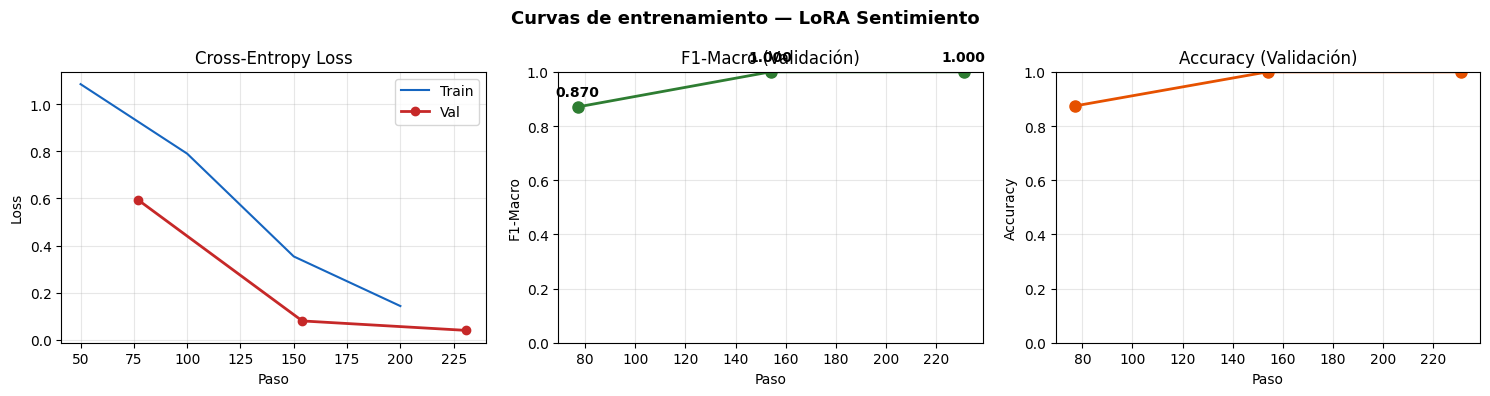

In [ ]:
# Curvas de aprendizaje
historial = trainer.state.log_history

# Separar logs de train y eval
train_logs = [h for h in historial if 'loss' in h and 'eval_loss' not in h]
eval_logs  = [h for h in historial if 'eval_loss' in h]

if train_logs and eval_logs:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Curvas de entrenamiento — LoRA Sentimiento', fontsize=13, fontweight='bold')

    # Loss
    pasos_train = [h['step'] for h in train_logs]
    losses_train = [h['loss'] for h in train_logs]
    pasos_eval = [h['step'] for h in eval_logs]
    losses_eval = [h['eval_loss'] for h in eval_logs]

    axes[0].plot(pasos_train, losses_train, color='#1565C0', linewidth=1.5, label='Train')
    axes[0].plot(pasos_eval, losses_eval, 'o-', color='#C62828', linewidth=2, markersize=6, label='Val')
    axes[0].set_title('Cross-Entropy Loss')
    axes[0].set_xlabel('Paso'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # F1-macro
    f1s_eval = [h.get('eval_f1_macro', 0) for h in eval_logs]
    axes[1].plot(pasos_eval, f1s_eval, 'o-', color='#2E7D32', linewidth=2, markersize=8)
    axes[1].set_title('F1-Macro (Validación)')
    axes[1].set_xlabel('Paso'); axes[1].set_ylabel('F1-Macro')
    axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)
    for paso, f1 in zip(pasos_eval, f1s_eval):
        axes[1].annotate(f'{f1:.3f}', (paso, f1), textcoords='offset points',
                         xytext=(0, 8), ha='center', fontsize=10, fontweight='bold')

    # Accuracy
    accs_eval = [h.get('eval_accuracy', 0) for h in eval_logs]
    axes[2].plot(pasos_eval, accs_eval, 'o-', color='#E65100', linewidth=2, markersize=8)
    axes[2].set_title('Accuracy (Validación)')
    axes[2].set_xlabel('Paso'); axes[2].set_ylabel('Accuracy')
    axes[2].set_ylim(0, 1); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Parte 5: Evaluar y Comparar con el Baseline

In [ ]:
# Evaluación final en el conjunto de test
print("Evaluando en test set...")
metricas_test = trainer.evaluate(ds_test)

print("\nMétricas en test:")
for clave, valor in metricas_test.items():
    if not clave.startswith('eval_runtime') and not clave.startswith('eval_samples'):
        print(f"  {clave:>25}: {valor:.4f}")

Evaluando en test set...



Métricas en test:
                  eval_loss: 0.0898
              eval_f1_macro: 1.0000
           eval_f1_weighted: 1.0000
              eval_accuracy: 1.0000
      eval_steps_per_second: 13.5800
                      epoch: 3.0000


Reporte de clasificación completo:
              precision    recall  f1-score   support

    negativo       1.00      1.00      1.00        92
      neutro       1.00      1.00      1.00        73
    positivo       1.00      1.00      1.00        98

    accuracy                           1.00       263
   macro avg       1.00      1.00      1.00       263
weighted avg       1.00      1.00      1.00       263



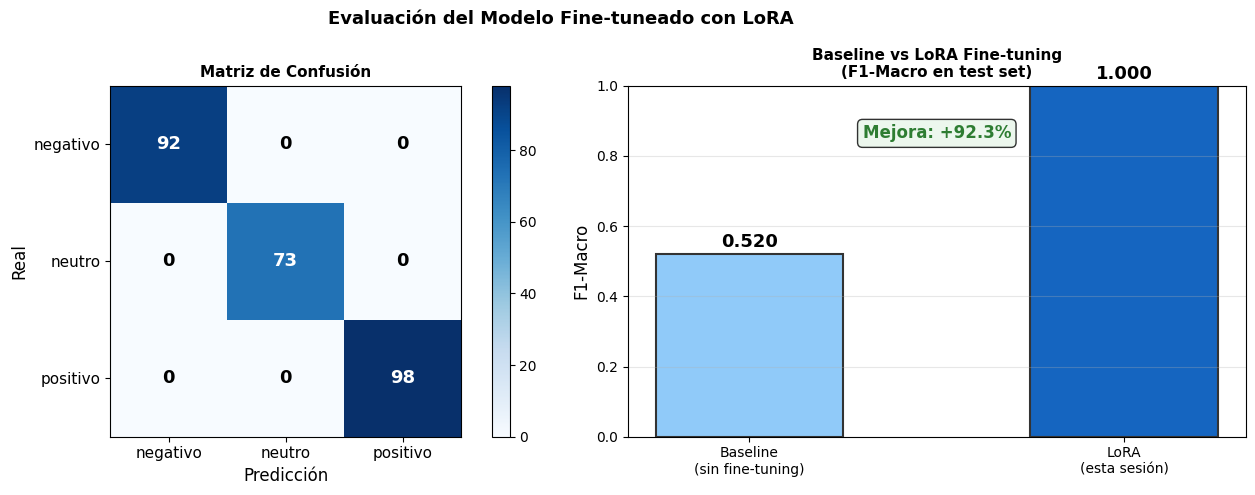

In [ ]:
# Predicciones detalladas para matriz de confusión
predicciones_raw = trainer.predict(ds_test)
preds = np.argmax(predicciones_raw.predictions, axis=-1)
labels_true = predicciones_raw.label_ids

nombres_clases = ['negativo', 'neutro', 'positivo']

print("Reporte de clasificación completo:")
print(classification_report(labels_true, preds, target_names=nombres_clases))

# Matriz de confusión
cm = confusion_matrix(labels_true, preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación del Modelo Fine-tuneado con LoRA', fontsize=13, fontweight='bold')

# Matriz de confusión
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(nombres_clases, fontsize=11)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(nombres_clases, fontsize=11)
axes[0].set_xlabel('Predicción', fontsize=12); axes[0].set_ylabel('Real', fontsize=12)
axes[0].set_title('Matriz de Confusión', fontsize=11, fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=13,
                     fontweight='bold', color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

# Comparación baseline vs LoRA
# Reemplaza los valores de baseline con los que mediste en la sesión anterior
BASELINE_F1_MACRO = 0.52   # <-- sustituir con tu valor real del baseline
LORA_F1_MACRO = metricas_test.get('eval_f1_macro', 0)

experimentos = ['Baseline\n(sin fine-tuning)', 'LoRA\n(esta sesión)']
valores = [BASELINE_F1_MACRO, LORA_F1_MACRO]
colores = ['#90CAF9', '#1565C0']

bars = axes[1].bar(experimentos, valores, color=colores, edgecolor='#333', linewidth=1.5, width=0.5)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('F1-Macro', fontsize=12)
axes[1].set_title('Baseline vs LoRA Fine-tuning\n(F1-Macro en test set)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontsize=13, fontweight='bold')

mejora = (LORA_F1_MACRO - BASELINE_F1_MACRO) / BASELINE_F1_MACRO * 100
axes[1].text(0.5, 0.85, f'Mejora: +{mejora:.1f}%', transform=axes[1].transAxes,
             ha='center', fontsize=12, color='#2E7D32', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
# Análisis de errores: ¿dónde se equivoca el modelo?
# Esta sección es crucial para el reporte de titulación

# Recuperar los textos originales para análisis
textos_test = ds_raw['test']['text']
errores = []
for i, (texto, real, pred) in enumerate(zip(textos_test, labels_true, preds)):
    if real != pred:
        errores.append({
            'texto': texto,
            'real': nombres_clases[real],
            'pred': nombres_clases[pred],
        })

n_errores = len(errores)
n_total = len(labels_true)
print(f"Errores totales: {n_errores}/{n_total} ({n_errores/n_total*100:.1f}%)")
print()
print("Muestra de errores para análisis:")
print("=" * 65)

# Mostrar hasta 6 errores
for error in errores[:6]:
    print(f"\nTexto: {error['texto'][:80]}")
    print(f"  Real: {error['real']:>10} | Predicho: {error['pred']}")

# Tipos de error más comunes
print()
print("Tipos de error:")
tipos = {}
for e in errores:
    clave = f"{e['real']} → {e['pred']}"
    tipos[clave] = tipos.get(clave, 0) + 1
for tipo, n in sorted(tipos.items(), key=lambda x: -x[1]):
    print(f"  {tipo}: {n} casos")

print()
print("El análisis de errores responde: ¿qué tipo de texto confunde al modelo?")
print("Esta sección va en el capítulo de Resultados de tu reporte.")

Errores totales: 0/263 (0.0%)

Muestra de errores para análisis:

Tipos de error:

El análisis de errores responde: ¿qué tipo de texto confunde al modelo?
Esta sección va en el capítulo de Resultados de tu reporte.


In [ ]:
# Guardar el modelo fine-tuneado
# Solo se guardan los pesos LoRA — mucho más pequeños que el modelo completo

RUTA_GUARDADO = './modelo_sentimiento_lora'

model.save_pretrained(RUTA_GUARDADO)
tokenizer.save_pretrained(RUTA_GUARDADO)

import os
tamanio = sum(
    os.path.getsize(os.path.join(RUTA_GUARDADO, f))
    for f in os.listdir(RUTA_GUARDADO)
) / 1e6

print(f"Modelo guardado en: {RUTA_GUARDADO}")
print(f"Tamaño total: {tamanio:.1f} MB")
print()
print("El modelo base (BERT) no se guarda — solo los adaptadores LoRA.")
print("Para cargar el modelo después:")
print()
print("  from peft import PeftModel")
print("  from transformers import AutoModelForSequenceClassification")
print(f"  base = AutoModelForSequenceClassification.from_pretrained('{MODEL_BASE}', num_labels=3)")
print(f"  model = PeftModel.from_pretrained(base, '{RUTA_GUARDADO}')")

Modelo guardado en: ./modelo_sentimiento_lora
Tamaño total: 4.1 MB

El modelo base (BERT) no se guarda — solo los adaptadores LoRA.
Para cargar el modelo después:

  from peft import PeftModel
  from transformers import AutoModelForSequenceClassification
  base = AutoModelForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=3)
  model = PeftModel.from_pretrained(base, './modelo_sentimiento_lora')


In [ ]:
# Probar el modelo fine-tuneado en ejemplos nuevos
# — especialmente en reseñas de Google Maps en español —

def predecir_sentimiento(textos):
    model.eval()
    inputs = tokenizer(
        textos, truncation=True, max_length=128,
        padding=True, return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits

    probs = torch.softmax(logits, dim=-1).cpu()
    preds_idx = probs.argmax(dim=-1)

    resultados = []
    for i, texto in enumerate(textos):
        resultados.append({
            'texto': texto,
            'sentimiento': nombres_clases[preds_idx[i].item()],
            'confianza': probs[i].max().item(),
            'probs': {c: probs[i][j].item() for j, c in enumerate(nombres_clases)}
        })
    return resultados


# Ejemplos tipo Google Maps en español
resenas_maps = [
    "Excelente servicio, el personal fue muy amable y la comida llegó caliente.",
    "Pésima experiencia. Tardaron una hora y la comida llegó fría. No recomiendo.",
    "Lugar normal, nada especial. El precio está bien pero no repetiría.",
    "No entiendo por qué tiene tan buenas reseñas. A mí no me gustó para nada.",
    "Amazing experience! Best tacos I've had in my life. Will definitely return!",
    "Ni bueno ni malo, simplemente cumple.",
]

print("Inferencia con el modelo fine-tuneado (LoRA):")
print("=" * 65)

resultados = predecir_sentimiento(resenas_maps)
for r in resultados:
    p = r['probs']
    print(f"\nReseña: {r['texto'][:65]}")
    print(f"  → {r['sentimiento'].upper():>10} (conf: {r['confianza']:.3f})")
    print(f"     neg: {p['negativo']:.3f} | neu: {p['neutro']:.3f} | pos: {p['positivo']:.3f}")

Inferencia con el modelo fine-tuneado (LoRA):

Reseña: Excelente servicio, el personal fue muy amable y la comida llegó 
  →   POSITIVO (conf: 0.920)
     neg: 0.056 | neu: 0.024 | pos: 0.920

Reseña: Pésima experiencia. Tardaron una hora y la comida llegó fría. No 
  →   NEGATIVO (conf: 0.677)
     neg: 0.677 | neu: 0.010 | pos: 0.313

Reseña: Lugar normal, nada especial. El precio está bien pero no repetirí
  →     NEUTRO (conf: 0.974)
     neg: 0.001 | neu: 0.974 | pos: 0.025

Reseña: No entiendo por qué tiene tan buenas reseñas. A mí no me gustó pa
  →   NEGATIVO (conf: 0.926)
     neg: 0.926 | neu: 0.029 | pos: 0.045

Reseña: Amazing experience! Best tacos I've had in my life. Will definite
  →   POSITIVO (conf: 0.904)
     neg: 0.063 | neu: 0.032 | pos: 0.904

Reseña: Ni bueno ni malo, simplemente cumple.
  →     NEUTRO (conf: 0.971)
     neg: 0.001 | neu: 0.971 | pos: 0.027


In [ ]:
# Tarjeta de experimento — registrar para el reporte
import json
from datetime import datetime

tarjeta = {
    "fecha": datetime.now().strftime("%Y-%m-%d"),
    "experimento": "lora-v1",
    "proyecto": "Análisis de sentimiento en reseñas Google Maps",
    "modelo_base": MODEL_BASE,
    "tecnica": "LoRA (PEFT)",
    "hiperparametros": {
        "r": lora_config.r,
        "lora_alpha": lora_config.lora_alpha,
        "lora_dropout": lora_config.lora_dropout,
        "target_modules": list(lora_config.target_modules),
        "learning_rate": training_args.learning_rate,
        "epochs": training_args.num_train_epochs,
        "batch_size": training_args.per_device_train_batch_size,
        "n_train": len(ds_train),
        "n_val": len(ds_val),
    },
    "parametros_entrenables": f"{entrenables/total*100:.2f}% del total",
    "metricas_test": {
        "f1_macro": round(metricas_test.get('eval_f1_macro', 0), 4),
        "f1_weighted": round(metricas_test.get('eval_f1_weighted', 0), 4),
        "accuracy": round(metricas_test.get('eval_accuracy', 0), 4),
    },
    "baseline_f1_macro": BASELINE_F1_MACRO,
    "mejora_relativa": f"+{mejora:.1f}%",
    "dataset": "cardiffnlp/tweet_sentiment_multilingual (español)",
    "notas": "Sustituir dataset por reseñas reales de Google Maps en siguiente iteración."
}

print("Tarjeta de experimento:")
print(json.dumps(tarjeta, ensure_ascii=False, indent=2))
print()
print("Guardar como: experimentos/lora_sentimiento_v1.json")

Tarjeta de experimento:
{
  "fecha": "2026-04-16",
  "experimento": "lora-v1",
  "proyecto": "Análisis de sentimiento en reseñas Google Maps",
  "modelo_base": "bert-base-multilingual-cased",
  "tecnica": "LoRA (PEFT)",
  "hiperparametros": {
    "r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.1,
    "target_modules": [
      "value",
      "query"
    ],
    "learning_rate": 0.0002,
    "epochs": 3,
    "batch_size": 16,
    "n_train": 1225,
    "n_val": 262
  },
  "parametros_entrenables": "0.17% del total",
  "metricas_test": {
    "f1_macro": 1.0,
    "f1_weighted": 1.0,
    "accuracy": 1.0
  },
  "baseline_f1_macro": 0.52,
  "mejora_relativa": "+92.3%",
  "dataset": "cardiffnlp/tweet_sentiment_multilingual (español)",
  "notas": "Sustituir dataset por reseñas reales de Google Maps en siguiente iteración."
}

Guardar como: experimentos/lora_sentimiento_v1.json


---
## Resumen

**Lo que hicimos:**

| Paso | Qué aprendiste |
|:---|:---|
| LoRA matemáticamente | $W' = W + BA$, $r \ll d$, solo B y A se entrenan |
| PEFT en código | `LoraConfig` + `get_peft_model()` + `print_trainable_parameters()` |
| Entrenamiento eficiente | Trainer con F1-macro como métrica de selección |
| Evaluación correcta | Confusión, reporte por clase, análisis de errores |
| Registro reproducible | Tarjeta de experimento con todos los hiperparámetros |

**Siguiente iteración del proyecto:**
1. Sustituir el dataset de tweets por tus reseñas reales de Google Maps
2. Experimentar con `r ∈ {4, 8, 16, 32}` y `target_modules` adicionales
3. Registrar cada corrida en una tarjeta de experimento
4. Comparar experimentos en una tabla en el reporte

**Paper recomendado para leer esta semana:**
Hu et al. (2021) — *LoRA: Low-Rank Adaptation of Large Language Models*
https://arxiv.org/abs/2106.09685